# Thesis Visualizations

Figures for the thesis results section, built from the CSV artifacts
produced by `thesis_experiment.ipynb`. Eight figures in priority order:

**Primary**
1. NMSE per descriptor × condition (DDSP vs baseline)
2. $R^2$ per descriptor × condition (reference vs DDSP vs baseline)
3. $\beta_1$ (slope) side-by-side + slope ratio
4. Dynamics: $\beta_2$ and $\beta_3$ two-panel deviation

**Secondary**
5. $\Delta R^2$ (reference minus synth)
6. Heatmap of key metrics × descriptor × condition

**Optional**
7. Cross-prediction scatter (spectral centroid)
8. All four $\beta$ terms for a focal descriptor

## Setup

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from evaluation.pitch_metrics import PitchMetrics
from visualize import _METHOD_COLORS  # keep colors consistent with other figs

ART_DIR = PROJECT_ROOT / "artifacts" / "evaluation" / "thesis_experiment"
FIG_DIR = ART_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Artifacts: {ART_DIR}")
print(f"Figures:   {FIG_DIR}")

Artifacts: /m/home/home3/37/thieun1/unix/Project/final_project/artifacts/evaluation/thesis_experiment
Figures:   /m/home/home3/37/thieun1/unix/Project/final_project/artifacts/evaluation/thesis_experiment/figures


## Configuration

In [14]:
DESCRIPTORS = [
    "spectral_centroid",
    "spectral_crest",
    "spectral_decrease",
    "spectral_flatness",
    "spectral_roll_off",
    "spectral_skewness",
    "spectral_spread",
]
SHORT = {
    "spectral_centroid":  "centroid",
    "spectral_crest":     "crest",
    "spectral_decrease":  "decrease",
    "spectral_flatness":  "flatness",
    "spectral_roll_off":  "roll_off",
    "spectral_skewness":  "skewness",
    "spectral_spread":    "spread",
}
SHORT_LABELS = [SHORT[d] for d in DESCRIPTORS]

# Four conditions: reference, two DDSP variants, and the WORLD/SMS baseline.
ALL_CONDITIONS   = ["reference", "ddsp", "ddsp_noreverb", "baseline"]
SYNTH_CONDITIONS = ["ddsp", "ddsp_noreverb", "baseline"]

# Display names for legends/axis ticks. Keep the raw keys above stable so
# they still match the `condition` column in the summary CSV.
DISPLAY = {
    "reference":     "reference",
    "ddsp":          "DDSP (rev.)",
    "ddsp_noreverb": "DDSP (no rev.)",
    "baseline":      "baseline",
}

# `_METHOD_COLORS` only covers reference/ddsp/baseline — add a distinct
# hue for the no-reverb DDSP variant.
COLORS = {
    "reference":     _METHOD_COLORS.get("reference", "0.6"),
    "ddsp":          _METHOD_COLORS.get("ddsp",      "steelblue"),
    "ddsp_noreverb": "cornflowerblue",
    "baseline":      _METHOD_COLORS.get("baseline",  "tomato"),
}

SAVE_DPI = 150


## Load data

Single long-form summary table is sufficient for figures 1–6 and 8.
Figure 7 (cross-prediction scatter) needs per-frame pred/actual pairs, so
it reloads the feature parquets.

In [25]:
summary = pd.read_csv(ART_DIR / "summary_per_descriptor_per_condition.csv")
print(f"summary: {summary.shape[0]} rows × {summary.shape[1]} cols")
summary.head(4)

summary: 28 rows × 19 cols


,condition,descriptor,n_voiced,R2,adj_R2,RMSE,b0_intercept,b1_log2f0,b2_p_dot,b3_p_ddot,delta_b0,delta_b1,delta_b2,delta_b3,slope_ratio_b1,delta_R2,cross_MSE,cross_NMSE,cross_R2
0,reference,spectral_centroid,32973,0.302936,0.302873,0.828282,-7.895052,0.890596,0.080035,0.004172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ddsp,spectral_centroid,64319,0.235216,0.235181,0.855572,-6.454431,0.895245,0.109836,0.001855,1.440621,0.004649,0.029801,-0.002317,1.005221,0.067720,2.924663,3.055635,-2.055635
2,ddsp_noreverb,spectral_centroid,81374,0.701476,0.701465,0.547364,-9.877209,1.241862,0.099421,0.010895,-1.982157,0.351267,0.019386,0.006723,1.394418,-0.398539,1.147036,1.142890,-0.142890
3,baseline,spectral_centroid,92581,0.102293,0.102264,0.933730,-2.066804,0.394085,0.025124,0.004168,5.828248,-0.496511,-0.054911,-0.000004,0.442496,0.200643,3.997811,4.116366,-3.116366


In [26]:
def pivot(df: pd.DataFrame, value_col: str, conditions=ALL_CONDITIONS) -> pd.DataFrame:
    """descriptor (rows, in DESCRIPTORS order) × condition (cols, in given order)."""
    p = df.pivot(index="descriptor", columns="condition", values=value_col)
    p = p.reindex(index=DESCRIPTORS)
    p = p.reindex(columns=[c for c in conditions if c in p.columns])
    return p

def grouped_bars(
    ax: plt.Axes,
    pivot_df: pd.DataFrame,
    *,
    ylabel: str,
    title: str,
    zero_line: bool = False,
    hlines: dict | None = None,
) -> None:
    conditions = list(pivot_df.columns)
    n_cond = len(conditions)
    n_desc = len(pivot_df.index)
    x = np.arange(n_desc)
    width = 0.8 / max(n_cond, 1)
    for j, cond in enumerate(conditions):
        vals = pivot_df[cond].to_numpy(dtype=float)
        ax.bar(
            x + j * width - (n_cond - 1) * width / 2,
            vals, width,
            label=DISPLAY.get(cond, cond),
            color=COLORS.get(cond, f"C{j}"),
            edgecolor="black", linewidth=0.3,
        )
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[d] for d in pivot_df.index], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if zero_line:
        ax.axhline(0, color="black", lw=0.5, ls="--")
    if hlines:
        for y, style in hlines.items():
            ax.axhline(y, **style)
    ax.legend(fontsize=8)

def save_fig(fig: plt.Figure, name: str) -> None:
    out = FIG_DIR / name
    fig.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
    print(f"saved {out.relative_to(PROJECT_ROOT)}")


## 1. NMSE per descriptor × condition (DDSP vs baseline)

Cross-prediction NMSE ($\text{MSE}/\text{Var}(y^{(c)})$): 0 is perfect,
1 means the reference model does no better than predicting the synth
mean. Only defined for synth conditions.

saved artifacts/evaluation/thesis_experiment/figures/fig1_cross_nmse.png


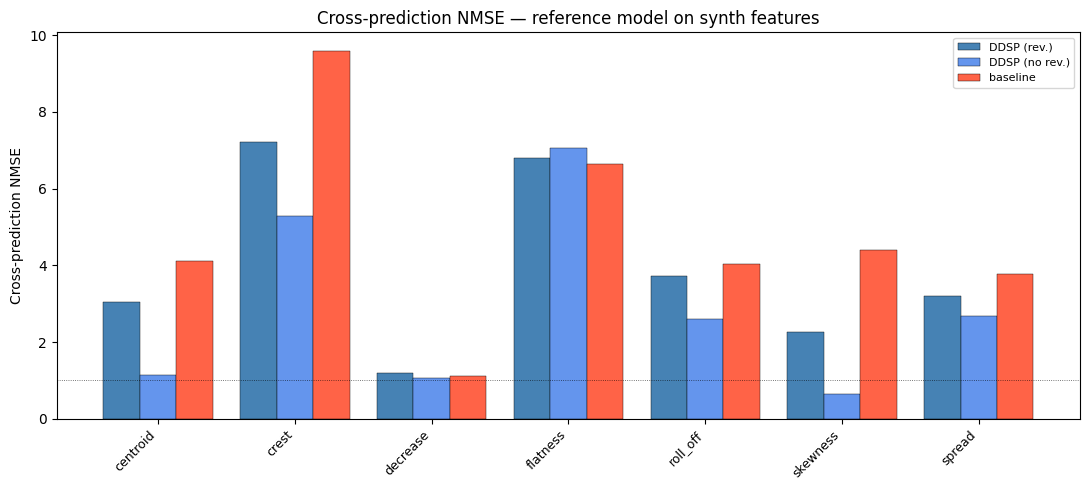

In [27]:
nmse_pv = pivot(summary, "cross_NMSE", conditions=SYNTH_CONDITIONS)
fig, ax = plt.subplots(figsize=(11, 5))
grouped_bars(
    ax, nmse_pv,
    ylabel="Cross-prediction NMSE",
    title="Cross-prediction NMSE — reference model on synth features",
    hlines={1.0: dict(color="black", lw=0.6, ls=":", alpha=0.7)},
)
plt.tight_layout()
save_fig(fig, "fig1_cross_nmse.png")
plt.show()


## 2. $R^2$ per descriptor × condition

Within-condition $R^2$ — how much of each descriptor is explained by
$[\log_2 f_0,\ \dot{p},\ \ddot{p}]$ for each condition. Three bars per
descriptor.

saved artifacts/evaluation/thesis_experiment/figures/fig2_r2.png


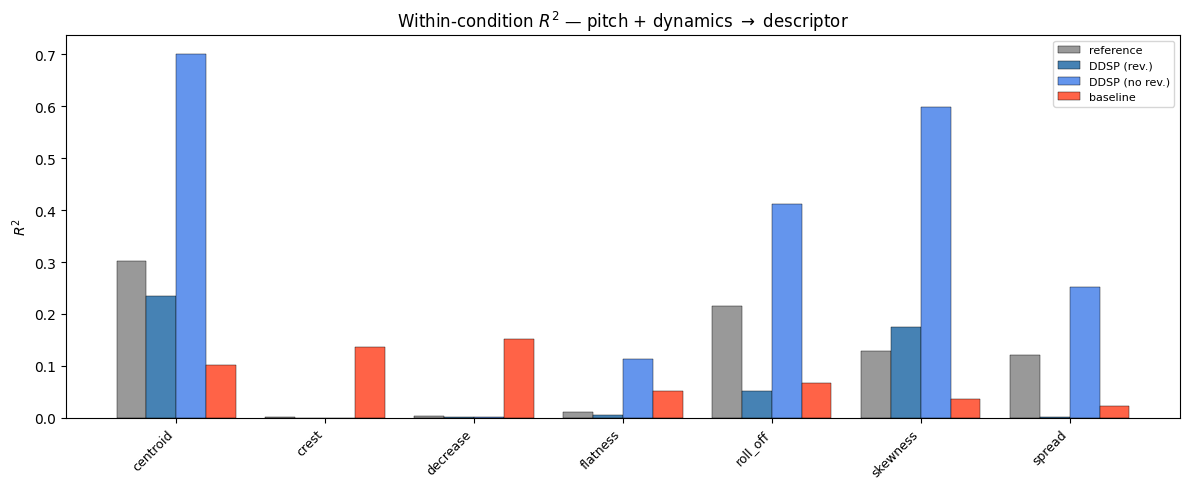

In [28]:
r2_pv = pivot(summary, "R2", conditions=ALL_CONDITIONS)
fig, ax = plt.subplots(figsize=(12, 5))
grouped_bars(
    ax, r2_pv,
    ylabel="$R^2$",
    title="Within-condition $R^2$ — pitch + dynamics $\\to$ descriptor",
)
plt.tight_layout()
save_fig(fig, "fig2_r2.png")
plt.show()


## 3. $\beta_1$ (static slope) and slope ratio

Two panels. **Left:** $\beta_1$ for reference, DDSP, baseline per
descriptor. **Right:** slope ratio $\beta_1^{(c)}/\beta_1^{\text{ref}}$
with a dashed line at $1.0$ marking perfect reproduction.

saved artifacts/evaluation/thesis_experiment/figures/fig3_beta1_and_slope_ratio.png


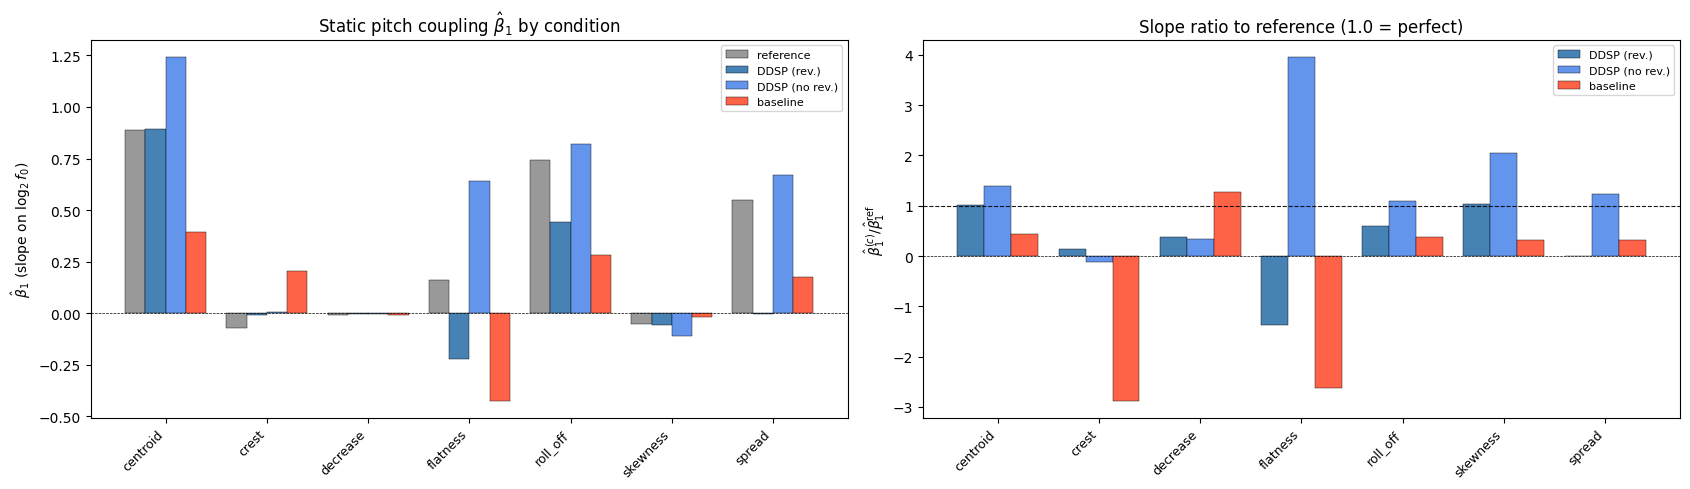

In [29]:
b1_pv    = pivot(summary, "b1_log2f0",      conditions=ALL_CONDITIONS)
ratio_pv = pivot(summary, "slope_ratio_b1", conditions=SYNTH_CONDITIONS)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
grouped_bars(
    axes[0], b1_pv,
    ylabel=r"$\hat{\beta}_1$ (slope on $\log_2 f_0$)",
    title=r"Static pitch coupling $\hat{\beta}_1$ by condition",
    zero_line=True,
)
grouped_bars(
    axes[1], ratio_pv,
    ylabel=r"$\hat{\beta}_1^{(c)} / \hat{\beta}_1^{\mathrm{ref}}$",
    title="Slope ratio to reference (1.0 = perfect)",
    zero_line=True,
    hlines={1.0: dict(color="black", lw=0.8, ls="--", alpha=0.9)},
)
plt.tight_layout()
save_fig(fig, "fig3_beta1_and_slope_ratio.png")
plt.show()


## 4. Dynamics deviation — $\beta_2$ (velocity) and $\beta_3$ (acceleration)

Two panels: coefficient **deviation from reference** for each dynamics
term, per descriptor. Bars at zero = method matches the reference.

saved artifacts/evaluation/thesis_experiment/figures/fig4_dynamics_deviation.png


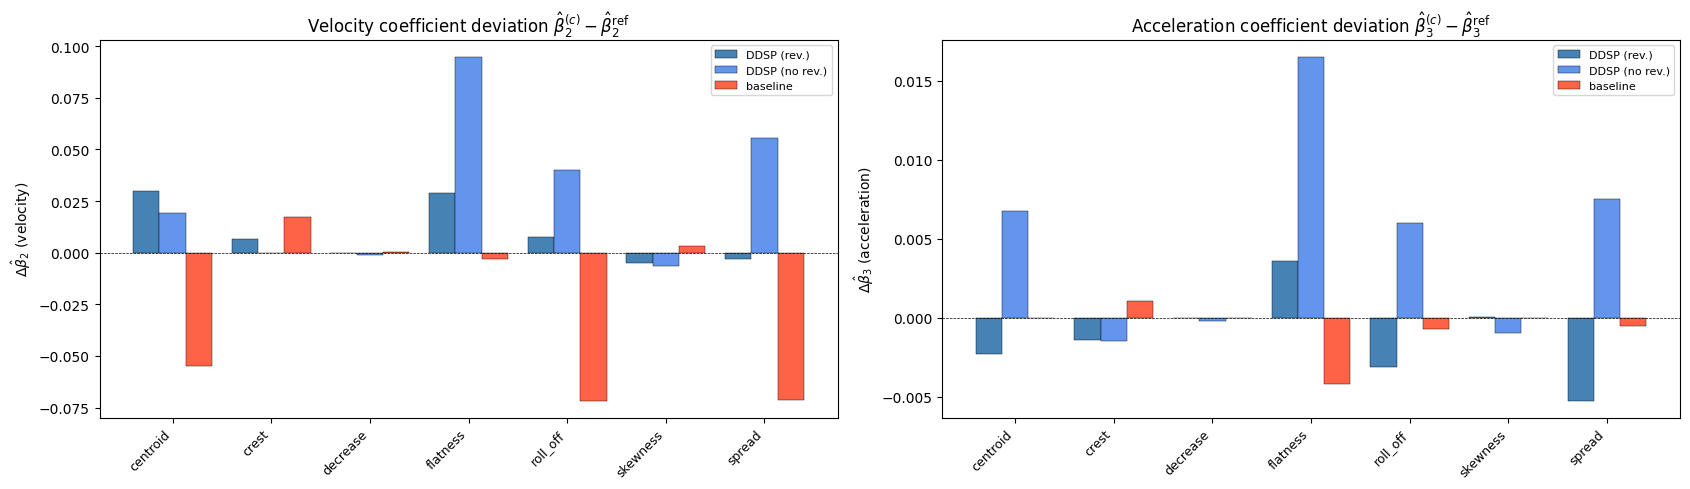

In [30]:
db2_pv = pivot(summary, "delta_b2", conditions=SYNTH_CONDITIONS)
db3_pv = pivot(summary, "delta_b3", conditions=SYNTH_CONDITIONS)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
grouped_bars(
    axes[0], db2_pv,
    ylabel=r"$\Delta\hat{\beta}_2$ (velocity)",
    title=r"Velocity coefficient deviation $\hat{\beta}_2^{(c)} - \hat{\beta}_2^{\mathrm{ref}}$",
    zero_line=True,
)
grouped_bars(
    axes[1], db3_pv,
    ylabel=r"$\Delta\hat{\beta}_3$ (acceleration)",
    title=r"Acceleration coefficient deviation $\hat{\beta}_3^{(c)} - \hat{\beta}_3^{\mathrm{ref}}$",
    zero_line=True,
)
plt.tight_layout()
save_fig(fig, "fig4_dynamics_deviation.png")
plt.show()


## 5. $\Delta R^2$ — reference minus synth

Positive bars = coupling weakened in the synth; negative = synth shows a
*stronger* linear coupling than the reference (the synth overshoots the
relationship).

saved artifacts/evaluation/thesis_experiment/figures/fig5_delta_r2.png


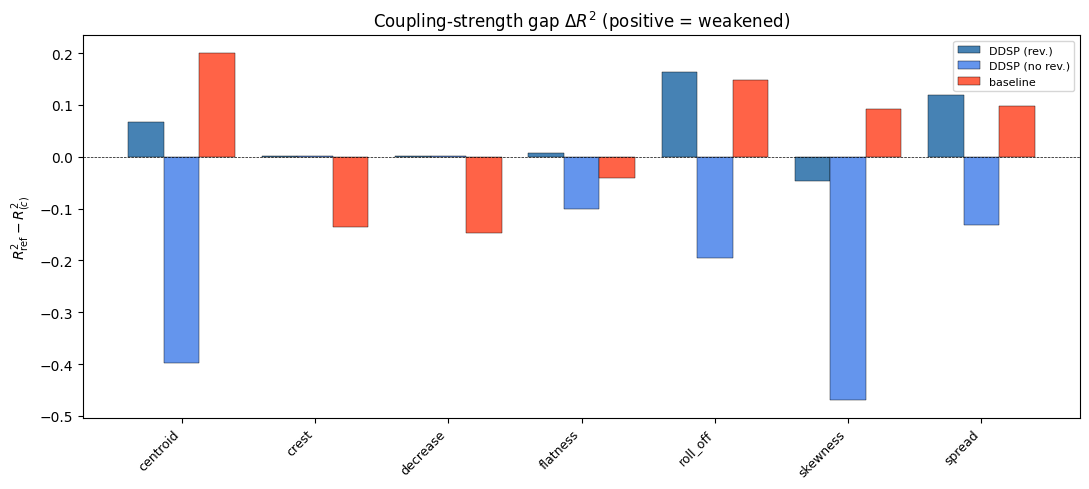

In [31]:
dr2_pv = pivot(summary, "delta_R2", conditions=SYNTH_CONDITIONS)
fig, ax = plt.subplots(figsize=(11, 5))
grouped_bars(
    ax, dr2_pv,
    ylabel=r"$R^2_{\mathrm{ref}} - R^2_{(c)}$",
    title=r"Coupling-strength gap $\Delta R^2$ (positive = weakened)",
    zero_line=True,
)
plt.tight_layout()
save_fig(fig, "fig5_delta_r2.png")
plt.show()


## 6. Heatmap — key metrics × descriptor × condition

Compact summary table: rows are descriptors, columns group three panels
(NMSE, $R^2$, slope ratio) by condition. Cells are colored and
annotated; per-panel colormap is chosen so green/neutral = good, red =
far from reference.

saved artifacts/evaluation/thesis_experiment/figures/fig6_heatmap.png


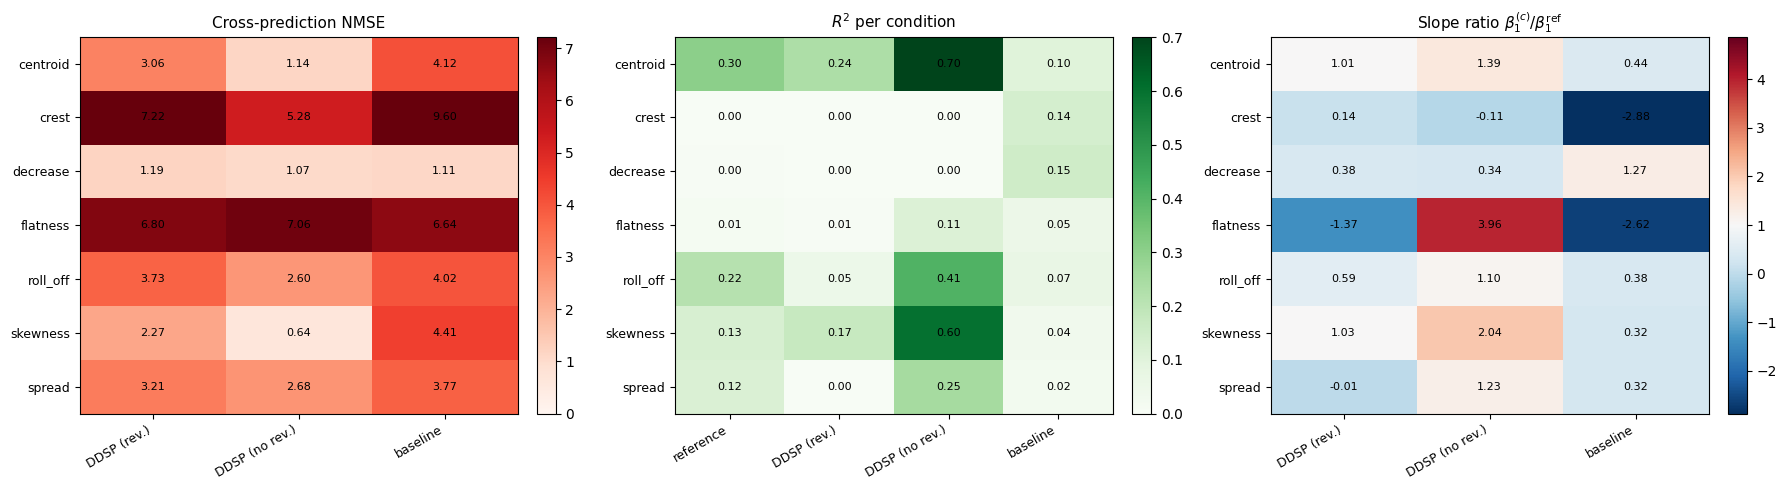

In [32]:
nmse_syn  = pivot(summary, "cross_NMSE",     conditions=SYNTH_CONDITIONS)
r2_all    = pivot(summary, "R2",             conditions=ALL_CONDITIONS)
ratio_syn = pivot(summary, "slope_ratio_b1", conditions=SYNTH_CONDITIONS)

def _heatmap(ax, data: pd.DataFrame, *, cmap, vmin, vmax, title, fmt="{:.2f}"):
    im = ax.imshow(data.to_numpy(dtype=float), aspect="auto",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels([DISPLAY.get(c, c) for c in data.columns],
                       rotation=30, ha="right", fontsize=9)
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels([SHORT[d] for d in data.index], fontsize=9)
    ax.set_title(title, fontsize=11)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iat[i, j]
            ax.text(j, i, fmt.format(v) if np.isfinite(v) else "",
                    ha="center", va="center", fontsize=8, color="black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# NMSE: 0 is best, clamp color scale so big values stay readable.
_heatmap(axes[0], nmse_syn,
         cmap="Reds", vmin=0.0, vmax=float(np.nanpercentile(nmse_syn, 95)),
         title="Cross-prediction NMSE")
# R²: neutral positive scale (slight headroom above max).
_heatmap(axes[1], r2_all,
         cmap="Greens", vmin=0.0, vmax=max(0.4, float(np.nanmax(r2_all))),
         title="$R^2$ per condition")
# Slope ratio: 1.0 = perfect; diverge around 1 with |ratio-1| scaling.
max_dev = float(np.nanmax(np.abs(ratio_syn - 1.0))) if ratio_syn.size else 1.0
_heatmap(axes[2], ratio_syn,
         cmap="RdBu_r", vmin=1.0 - max_dev, vmax=1.0 + max_dev,
         title=r"Slope ratio $\beta_1^{(c)}/\beta_1^{\mathrm{ref}}$")

plt.tight_layout()
save_fig(fig, "fig6_heatmap.png")
plt.show()


## 7. Cross-prediction scatter (spectral centroid)

Visualize what NMSE captures: for each voiced frame, plot the
reference-model-predicted descriptor value against the *actual*
synthesized descriptor value. Perfect agreement lies on $y = x$. One
subplot per synth condition.

saved artifacts/evaluation/thesis_experiment/figures/fig7_scatter_spectral_centroid.png


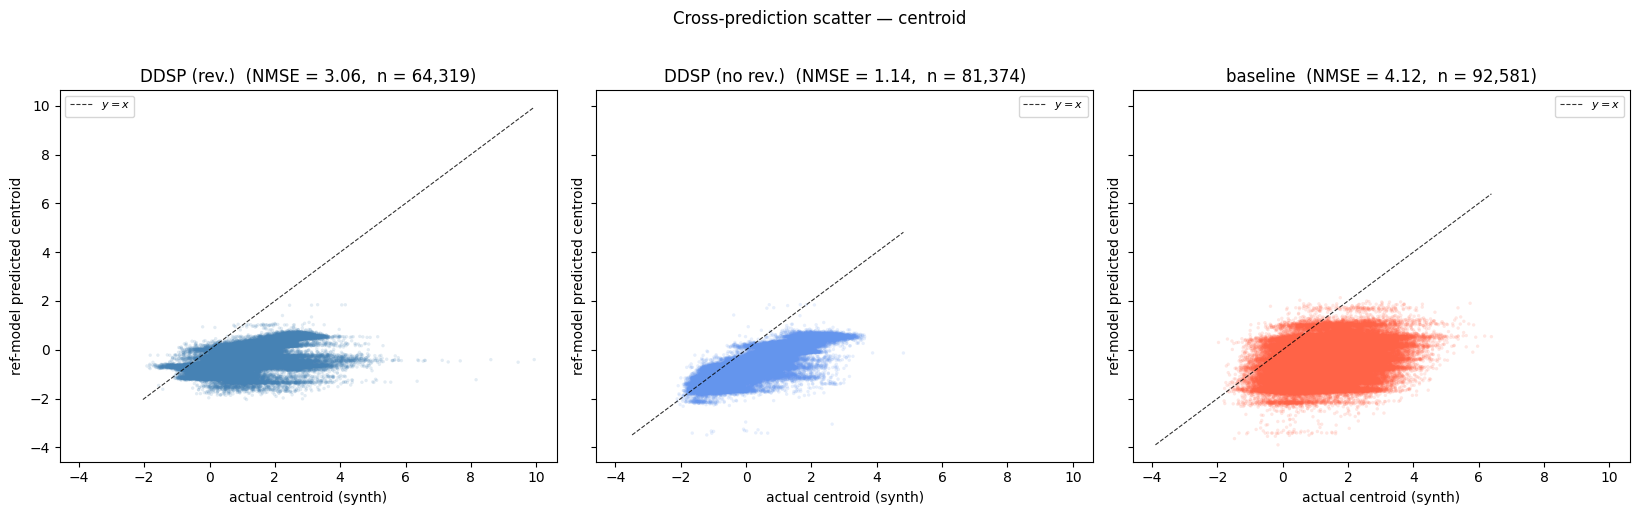

In [33]:
# Reload what we need to rebuild per-frame predictions for the scatter.
PITCH_TRANSFORM      = "log2"
CONFIDENCE_THRESHOLD = 0.50
MEDIAN_WINDOW        = 5
FRAME_WIDTH          = 0.25
OVERLAP              = 0.0
dt = FRAME_WIDTH * (1.0 - OVERLAP)

FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "normalized"
COND_PARQUET = {
    "reference":     FEATURE_DIR / "bach_features_norm.parquet",
    "ddsp":          FEATURE_DIR / "transfered_features_norm.parquet",
    "ddsp_noreverb": FEATURE_DIR / "transfered_noreverb_features_norm.parquet",
    "baseline":      FEATURE_DIR / "baseline_features_norm.parquet",
}

def _load(path: Path):
    df = pd.read_parquet(path)
    f0 = df["f0_hz"].to_numpy(dtype=np.float64)
    f0[df["f0_confidence"].to_numpy() < CONFIDENCE_THRESHOLD] = np.nan
    feats = df[DESCRIPTORS].to_numpy(dtype=np.float64)
    return f0, feats

ref_f0, ref_feats = _load(COND_PARQUET["reference"])
ref_models = PitchMetrics.fit(
    ref_feats, ref_f0, DESCRIPTORS,
    regressors="B", method="ols",
    dt=dt, pitch_transform=PITCH_TRANSFORM, median_window=MEDIAN_WINDOW,
)

FOCAL = "spectral_centroid"
focal_idx = DESCRIPTORS.index(FOCAL)

fig, axes = plt.subplots(1, len(SYNTH_CONDITIONS),
                         figsize=(5.5 * len(SYNTH_CONDITIONS), 5),
                         sharex=True, sharey=True)
if len(SYNTH_CONDITIONS) == 1:
    axes = [axes]

for ax, cond in zip(axes, SYNTH_CONDITIONS):
    f0, feats = _load(COND_PARQUET[cond])
    predicted = PitchMetrics.predict(f0, ref_models, DESCRIPTORS)
    y_true = feats[:, focal_idx]
    y_pred = predicted[:, focal_idx]
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = y_true[mask], y_pred[mask]

    nmse = float(summary.query("condition == @cond and descriptor == @FOCAL")["cross_NMSE"].iloc[0])
    ax.scatter(yt, yp, s=6, alpha=0.15, color=COLORS[cond], edgecolors="none")
    lo = float(np.nanmin([yt.min(), yp.min()]))
    hi = float(np.nanmax([yt.max(), yp.max()]))
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.8, label="$y = x$")
    ax.set_xlabel(f"actual {SHORT[FOCAL]} (synth)")
    ax.set_ylabel(f"ref-model predicted {SHORT[FOCAL]}")
    ax.set_title(f"{DISPLAY[cond]}  (NMSE = {nmse:.2f},  n = {mask.sum():,})")
    ax.legend(fontsize=8, loc="best")

fig.suptitle(f"Cross-prediction scatter — {SHORT[FOCAL]}", y=1.02, fontsize=12)
plt.tight_layout()
save_fig(fig, f"fig7_scatter_{FOCAL}.png")
plt.show()


## 8. All four $\beta$ terms for a focal descriptor

Case-study view of a single descriptor (default: spectral centroid,
which has the cleanest pitch coupling). Shows $\beta_0$–$\beta_3$ side
by side for reference, DDSP, baseline. $\beta_0$ is on a separate panel
because intercepts live on a very different scale from slopes in this
(normalized) feature space.

saved artifacts/evaluation/thesis_experiment/figures/fig8_coeffs_spectral_centroid.png


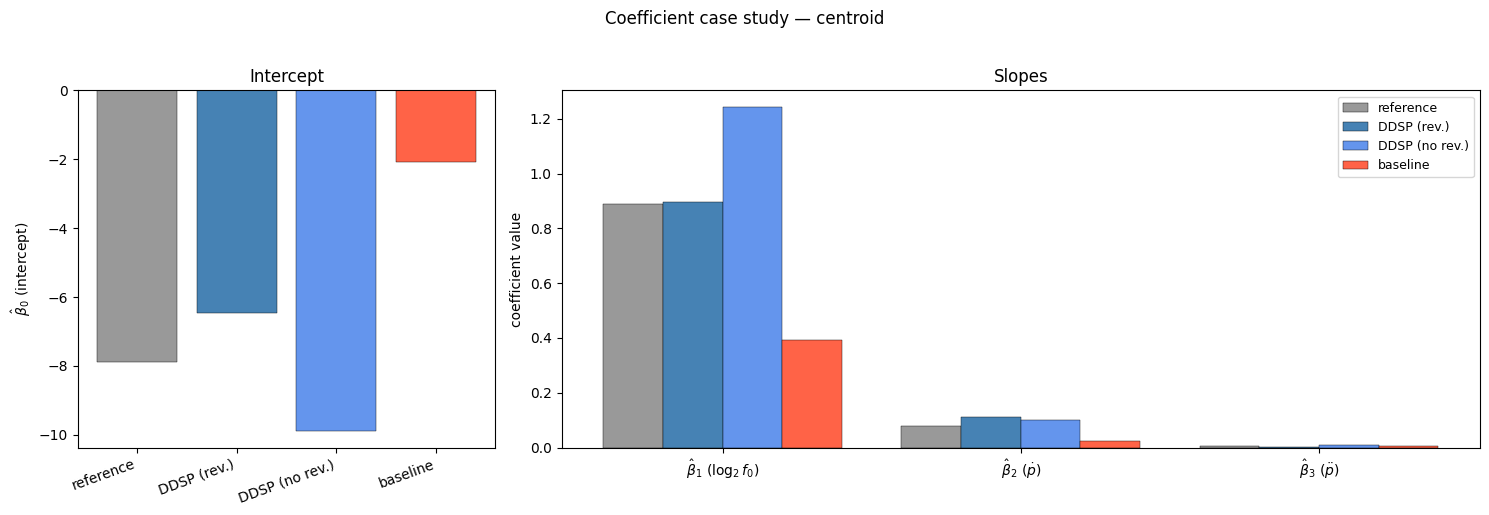

In [34]:
FOCAL = "spectral_centroid"  # flip to any descriptor for a different case study
focal_rows = summary[summary["descriptor"] == FOCAL].set_index("condition").reindex(ALL_CONDITIONS)

SLOPE_COLS = [("b1_log2f0", r"$\hat{\beta}_1\ (\log_2 f_0)$"),
              ("b2_p_dot",  r"$\hat{\beta}_2\ (\dot{p})$"),
              ("b3_p_ddot", r"$\hat{\beta}_3\ (\ddot{p})$")]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2.2]})

# Panel A: intercept
intercepts = focal_rows["b0_intercept"].to_numpy(dtype=float)
x0 = np.arange(len(ALL_CONDITIONS))
axes[0].bar(x0, intercepts,
            color=[COLORS[c] for c in ALL_CONDITIONS], edgecolor="black", linewidth=0.3)
axes[0].axhline(0, color="black", lw=0.5, ls="--")
axes[0].set_xticks(x0)
axes[0].set_xticklabels([DISPLAY[c] for c in ALL_CONDITIONS], rotation=20, ha="right")
axes[0].set_ylabel(r"$\hat{\beta}_0$ (intercept)")
axes[0].set_title("Intercept")

# Panel B: grouped bars for the three slopes
x = np.arange(len(SLOPE_COLS))
n_cond = len(ALL_CONDITIONS)
width = 0.8 / n_cond
for j, cond in enumerate(ALL_CONDITIONS):
    vals = [focal_rows.loc[cond, col] for col, _ in SLOPE_COLS]
    axes[1].bar(x + j * width - (n_cond - 1) * width / 2, vals, width,
                label=DISPLAY[cond], color=COLORS[cond], edgecolor="black", linewidth=0.3)
axes[1].axhline(0, color="black", lw=0.5, ls="--")
axes[1].set_xticks(x)
axes[1].set_xticklabels([lbl for _, lbl in SLOPE_COLS])
axes[1].set_ylabel("coefficient value")
axes[1].set_title("Slopes")
axes[1].legend(fontsize=9)

fig.suptitle(f"Coefficient case study — {SHORT[FOCAL]}", fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, f"fig8_coeffs_{FOCAL}.png")
plt.show()
